### Postprocessing of data extracted by the Sniffer.

This notebook contains development scripts - most of this will be automated in the Sniffer: `run_postprocessing` will run following the full data extraction.

### TODO: add data types and physiological bounds to schema (and 'normal bounds'?). Add derived variables and forumlae? Add unit conversion functions?

#### TODO: add discharge time to schema (and run Sniffer with only this variable -> add to mapping and extract manually).
#### TODO: add functionality to append to a pre-existing schema or project, without having to redo the full mapping.

In [1]:
import sqlite3
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import os
os.chdir('../streamlit/')
from utilities import LocalDatabaseWrapper
os.chdir('../development')

# %matplotlib_inline

In [70]:
project_name = "smartt_bmj_open_plus"
database_path = Path("../data")

In [71]:
local_db = LocalDatabaseWrapper(
            database_path / f"{project_name}.db"
        )

In [5]:
# Already has been run!
# local_db.insert_query(
#     "CREATE INDEX intervention_attribute ON full_extract (interventionId, attributeId);"
# )

In [72]:
# Check that index has been added (if not, uncomment and run above cell).
local_db.query_pd("PRAGMA index_list('full_extract');")

,seq,name,unique,origin,partial
0,0,intervention_attribute,0,c,0


In [73]:
local_db.query_pd(
    "select * from sqlite_master where type = 'table';"
    
)

,type,name,tbl_name,rootpage,sql
0,table,schema,schema,2,"CREATE TABLE ""schema"" (\n""mapping_complete"" IN..."
1,table,info,info,5,"CREATE TABLE ""info"" (\n""name"" TEXT,\n ""databa..."
2,table,clinical_unit_ids,clinical_unit_ids,6,"CREATE TABLE ""clinical_unit_ids"" (\n""Select"" I..."
3,table,fact_table_init_status,fact_table_init_status,7,"CREATE TABLE ""fact_table_init_status"" (\n""tabl..."
4,table,PtAssessmentInterventions,PtAssessmentInterventions,9,"CREATE TABLE ""PtAssessmentInterventions"" (\n""i..."
5,table,PtLabResultInterventions,PtLabResultInterventions,79,"CREATE TABLE ""PtLabResultInterventions"" (\n""in..."
6,table,PtDemographicInterventions,PtDemographicInterventions,109,"CREATE TABLE ""PtDemographicInterventions"" (\n""..."
7,table,table_definitions,table_definitions,116,"CREATE TABLE ""table_definitions"" (\n""tableType..."
8,table,distinct_attributes,distinct_attributes,119,"CREATE TABLE ""distinct_attributes"" (\n""attribu..."
9,table,example_attribute_data,example_attribute_data,120,"CREATE TABLE ""example_attribute_data"" (\n""attr..."


In [5]:
final_mapping = local_db.query_pd(
    "select * from final_mapping;"
    
)
final_mapping 

,schemaVariable,interventionId,interventionLongLabel,priority,attributeId,attributeShortLabel,tableName
0,Gender,2631,Gender,0,11050,Gender,PtDemographic
1,BMI,2645,Body Mass Index,0,3723,BMI,PtDemographic
2,Weight,2110,Weight (admission),0,3588,Admit weight,PtDemographic
3,Weight,2110,Weight (admission),0,40554,Admit weight,PtDemographic
4,Weight,4615,Weight (Admission),0,1636,Weight,PtDemographic
...,...,...,...,...,...,...,...
138,Endotracheal tube,2316,ETT/Trache Cuff Inflated,0,6064,Cuff Inflated,PtAssessment
139,Endotracheal tube,25519,ETT/Trache Cuff Inflated,0,46466,Cuff Inflated,PtAssessment
140,Endotracheal tube,25519,ETT/Trache Cuff Inflated,0,46467,Pressure,PtAssessment
141,Endotracheal tube,70054,ETT/Trache Cuff Inflated,0,74755,Cuff Inflated,PtAssessment


In [6]:
unique_variables = final_mapping.schemaVariable.unique()

In [7]:
len(unique_variables)

37

In [8]:
final_mapping[final_mapping.schemaVariable == unique_variables[20]]

,schemaVariable,interventionId,interventionLongLabel,priority,attributeId,attributeShortLabel,tableName
60,Heart rate,3361,Heart Rate,0,12754,HR,PtAssessment
61,Heart rate,7838,Heart Rate,0,27308,HR,PtAssessment
62,Heart rate,7838,Heart Rate,0,27309,HR,PtAssessment
63,Heart rate,7838,Heart Rate,0,27312,HR,PtAssessment


In [9]:
df = local_db.query_pd(
    "select * from full_extract where interventionId = 7838 and attributeId = 27312;"
)

In [10]:
len(df.encounterId.unique())

20679

In [16]:
df.valueNumber = pd.to_numeric(df.valueNumber)

In [17]:
df.valueNumber.mean()

np.float64(83.20417518431671)

In [33]:
df.valueNumber.isna().sum()

np.int64(1170)

In [35]:
df = df[~df.valueNumber.isna()]

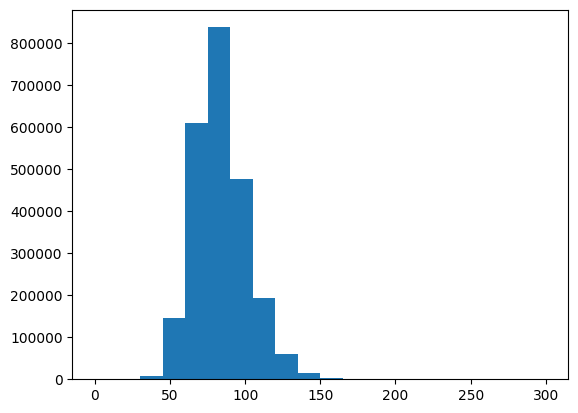

In [37]:
plt.hist(df.valueNumber, bins=20);

{'bodies': [<matplotlib.collections.PolyCollection at 0x210371f9190>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x210364fea90>,
 'cmins': <matplotlib.collections.LineCollection at 0x21037296bd0>,
 'cbars': <matplotlib.collections.LineCollection at 0x2103695bf10>}

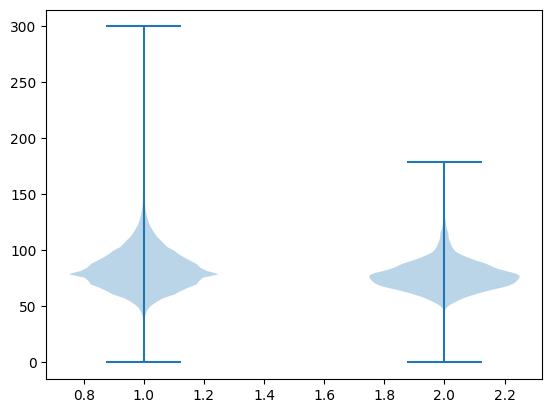

In [39]:
plt.violinplot([df.valueNumber, df.valueNumber.array[0:5000]], )

In [41]:
unique_variables

array(['Gender', 'BMI', 'Weight', 'Height', 'DOB', 'Ethnicity',
       'Postcode', 'Admit source', 'Hospital Number', 'Pao2',
       'actual bicarbonate', 'arterial oxygen saturation', 'Hemoglobin',
       'platelet count', 'Sodium', 'potassium', 'creatinine', 'urea',
       'C-reactive protein', 'Bilirubin', 'Heart rate',
       'arterial blood pressure (systolic)',
       'arterial blood pressure (diastolic)',
       'arterial blood pressure (mean)',
       'noninvasive blood pressure (systolic)',
       'noninvasive blood pressure (diastolic)', 'temperature', 'Fio2',
       'positive end-expiratory pressure', 'tidal volume',
       'respiratory rate', 'peripheral oxygen saturation',
       'Glasgow Coma Scale', 'Richmond Agitation-Sedation Scale',
       'Pao2/Fio2', 'Urine output', 'Endotracheal tube'], dtype=object)

In [42]:
local_db.query_pd(
    "select * from final_mapping where tableName='PtDemographic';"
    
)

,schemaVariable,interventionId,interventionLongLabel,priority,attributeId,attributeShortLabel,tableName
0,Gender,2631,Gender,0,11050,Gender,PtDemographic
1,BMI,2645,Body Mass Index,0,3723,BMI,PtDemographic
2,Weight,2110,Weight (admission),0,3588,Admit weight,PtDemographic
3,Weight,2110,Weight (admission),0,40554,Admit weight,PtDemographic
4,Weight,4615,Weight (Admission),0,1636,Weight,PtDemographic
5,Weight,4615,Weight (Admission),0,34296,Weight,PtDemographic
6,Weight,4615,Weight (Admission),0,34301,Weight,PtDemographic
7,Weight,8906,Weight (prescribing),0,33390,Weight,PtDemographic
8,Weight,8917,Weight (Prescribing),0,1636,Weight,PtDemographic
9,Weight,8917,Weight (Prescribing),0,34296,Weight,PtDemographic


In [188]:
admit_discharge_times = local_db.query_pd(
    """
    select encounterId, MIN(chartTime) as admitDateTime, MAX(chartTime) as dischargeDateTime, MIN(utcChartTime) as utcAdmitDateTime, MAX(utcChartTime) as utcDischargeDateTime, MIN(storeTime) as admitStoreDateTime, MAX(storeTime) as dischargeStoreDateTime from full_extract
    group by encounterId;
    """  
)

In [81]:
all_t_numbers = local_db.query_pd(
    "select * from full_extract where interventionId=2402 and attributeId=18476;"
    
)

In [190]:
admit_discharge_times

,encounterId,admitDateTime,dischargeDateTime,utcAdmitDateTime,utcDischargeDateTime,admitStoreDateTime,dischargeStoreDateTime
0,1,2014-12-31 02:35:00,2015-01-30 08:56:00,2014-12-31 02:35:00,2015-01-30 08:56:00,2015-01-30 08:56:00.927000,2015-01-30 16:22:11.377000
1,2,2015-01-28 12:29:00,2015-01-30 08:48:00,2015-01-28 12:29:00,2015-01-30 08:48:00,2015-01-30 08:48:35.880000,2015-01-30 08:49:53.073000
2,3,2015-01-30 08:55:00,2015-01-30 08:55:00,2015-01-30 08:55:00,2015-01-30 08:55:00,2015-01-30 08:55:56.460000,2015-01-30 08:55:56.867000
3,4,2015-01-30 08:52:00,2015-01-30 08:52:00,2015-01-30 08:52:00,2015-01-30 08:52:00,2015-01-30 08:52:36.463000,2015-01-30 08:52:36.863000
4,7,2015-01-30 08:56:00,2015-01-30 08:56:00,2015-01-30 08:56:00,2015-01-30 08:56:00,2015-01-30 08:56:42.760000,2015-01-30 08:56:43.210000
...,...,...,...,...,...,...,...
23495,37011,2023-08-08 18:27:00,2023-08-09 23:00:00,2023-08-08 17:27:00,2023-08-09 22:00:00,2023-08-09 10:54:44.893000,2023-08-09 22:58:10.330000
23496,37013,2023-07-24 15:16:00,2023-08-09 23:36:00,2023-07-24 14:16:00,2023-08-09 22:36:00,2023-08-09 12:27:15.870000,2023-08-09 23:38:57.300000
23497,37014,2023-08-09 13:42:00,2023-08-09 13:42:00,2023-08-09 12:42:00,2023-08-09 12:42:00,2023-08-09 13:43:07.760000,2023-08-09 13:43:07.760000
23498,37015,2023-08-09 13:51:00,2023-08-09 13:51:00,2023-08-09 12:51:00,2023-08-09 12:51:00,2023-08-09 13:51:55.757000,2023-08-09 13:51:55.773000


In [191]:
admit_discharge_times.admitDateTime = pd.to_datetime(admit_discharge_times.admitDateTime)
admit_discharge_times.dischargeDateTime = pd.to_datetime(admit_discharge_times.dischargeDateTime)

admit_discharge_times.utcAdmitDateTime = pd.to_datetime(admit_discharge_times.utcAdmitDateTime)
admit_discharge_times.utcDischargeDateTime = pd.to_datetime(admit_discharge_times.utcDischargeDateTime)

admit_discharge_times.admitStoreDateTime = pd.to_datetime(admit_discharge_times.admitStoreDateTime, format='mixed')
admit_discharge_times.dischargeStoreDateTime = pd.to_datetime(admit_discharge_times.dischargeStoreDateTime, format='mixed')

In [192]:
DAY_0 = admit_discharge_times.iloc[0].admitDateTime.date()

In [193]:
DAY_0

datetime.date(2014, 12, 31)

In [149]:
df.columns

Index(['attributeId', 'interventionId', 'encounterId', 'attributeShortLabel',
       'attributeLongLabel', 'clinicalUnitId', 'terseForm', 'verboseForm',
       'valueNumber', 'valueString', 'valueDateTime', 'unitOfMeasure',
       'chartTime', 'storeTime', 'utcChartTime', 'careProviderId',
       'tableTypeId', 'bedId', 'lowerNormal', 'upperNormal',
       'attributeConceptLabel', 'attributeConceptCode'],
      dtype='object')

In [194]:
# admit_discharge_times['admitDay'] = admit_discharge_times.admitDateTime.apply(
#     lambda x: (x.date() - DAY_0).days
# )
admit_discharge_times['admitDay'] = admit_discharge_times.admitStoreDateTime.apply(
    lambda x: (x.date() - DAY_0).days
)

In [195]:
# admit_discharge_times['dischargeDay'] = admit_discharge_times.dischargeDateTime.apply(
#     lambda x: (x.date() - DAY_0).days
# )
admit_discharge_times['dischargeDay'] = admit_discharge_times.dischargeStoreDateTime.apply(
    lambda x: (x.date() - DAY_0).days
)

In [196]:
icca_cohort = all_t_numbers[['encounterId', 'clinicalUnitId', 'valueString', 'bedId']].merge(admit_discharge_times, on='encounterId', how='inner')

In [197]:
icca_cohort.rename(columns={'valueString': 'Hospital number'}, inplace=True)

In [227]:
df.head()

,attributeId,interventionId,encounterId,attributeShortLabel,attributeLongLabel,clinicalUnitId,terseForm,verboseForm,valueNumber,valueString,...,chartTime,storeTime,utcChartTime,careProviderId,tableTypeId,bedId,lowerNormal,upperNormal,attributeConceptLabel,attributeConceptCode
0,27312,7838,1583,HR,Heart Rate.HR.Heart Rate,5,75,75 bpm,75.0,None,...,2015-06-16 16:00:00,2015-06-16 16:00:34.287000,2015-06-16 15:00:00,4,4,35,50.0,120.0,Heart rate (observable entity),364075005
1,27312,7838,1583,HR,Heart Rate.HR.Heart Rate,5,74,74 bpm,74.0,None,...,2015-06-16 17:00:00,2015-06-16 17:00:11.627000,2015-06-16 16:00:00,4,4,35,50.0,120.0,Heart rate (observable entity),364075005
2,27312,7838,1583,HR,Heart Rate.HR.Heart Rate,5,76,76 bpm,76.0,None,...,2015-06-16 18:00:00,2015-06-16 18:00:15.640000,2015-06-16 17:00:00,4,4,35,50.0,120.0,Heart rate (observable entity),364075005
3,27312,7838,1583,HR,Heart Rate.HR.Heart Rate,5,75,75 bpm,75.0,None,...,2015-06-16 19:00:00,2015-06-16 19:00:13.877000,2015-06-16 18:00:00,4,4,35,50.0,120.0,Heart rate (observable entity),364075005
4,27312,7838,1583,HR,Heart Rate.HR.Heart Rate,5,78,78 bpm,78.0,None,...,2015-06-16 20:00:00,2015-06-16 20:00:15.323000,2015-06-16 19:00:00,4,4,35,50.0,120.0,Heart rate (observable entity),364075005


In [231]:
min_hr_chart = df.groupby('encounterId').agg({'chartTime': 'min'})

In [233]:
icca_cohort = icca_cohort.merge(min_hr_chart, on='encounterId', how='inner')

In [315]:
# icca_cohort['admitDay'] = pd.to_datetime(icca_cohort.chartTime).apply(
#     lambda x: (x.date() - DAY_0).days
# )
icca_cohort['admitDay'] = pd.to_datetime(icca_cohort.admitStoreDateTime).apply(
    lambda x: (x.date() - DAY_0).days
)

In [316]:
icca_cohort

,encounterId,clinicalUnitId,Hospital number,bedId,admitDateTime,dischargeDateTime,utcAdmitDateTime,utcDischargeDateTime,admitStoreDateTime,dischargeStoreDateTime,admitDay,dischargeDay,chartTime
0,1583,5,T6356880,36,2015-04-21 18:08:00,2015-07-20 12:00:00,2015-04-21 17:08:00,2015-07-20 11:00:00,2015-04-22 02:56:30.483,2015-07-20 17:00:15.720,112,201,2015-06-16 16:00:00
1,1870,8,T5981205,1,2015-05-20 00:00:00,2015-06-26 10:23:00,2015-05-19 23:00:00,2015-06-26 09:23:00,2015-05-20 17:14:38.660,2015-06-26 13:13:31.637,140,177,2015-06-16 16:00:00
2,1924,5,T5581109,23,2015-05-26 17:08:00,2015-06-28 10:13:00,2015-05-26 16:08:00,2015-06-28 09:13:00,2015-05-26 22:39:45.440,2015-06-28 11:09:17.520,146,179,2015-06-16 16:00:00
3,1946,5,T5891905,1,2015-05-29 01:00:00,2015-06-23 07:17:00,2015-05-29 00:00:00,2015-06-23 06:17:00,2015-05-29 01:25:27.000,2015-06-23 10:57:25.837,149,174,2015-06-16 16:00:00
4,1959,5,T6750023,34,2015-05-23 08:00:00,2015-08-11 05:51:00,2015-05-23 07:00:00,2015-08-11 04:51:00,2015-05-29 23:56:09.940,2015-08-11 06:58:42.890,149,223,2015-06-16 19:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20817,37008,8,T8791522,1,2023-08-09 06:54:00,2023-08-09 23:00:00,2023-08-09 05:54:00,2023-08-09 22:00:00,2023-08-09 08:34:59.377,2023-08-09 23:30:53.290,3143,3143,2023-08-09 15:36:00
20818,37009,5,T8126247,1,2023-08-09 04:01:00,2023-08-09 23:00:00,2023-08-09 03:01:00,2023-08-09 22:00:00,2023-08-09 09:20:19.273,2023-08-09 23:34:31.150,3143,3143,2023-08-09 09:37:00
20819,37011,8,T8761204,1,2023-08-08 18:27:00,2023-08-09 23:00:00,2023-08-08 17:27:00,2023-08-09 22:00:00,2023-08-09 10:54:44.893,2023-08-09 22:58:10.330,3143,3143,2023-08-09 21:00:00
20820,37013,5,T6525356,1,2023-07-24 15:16:00,2023-08-09 23:36:00,2023-07-24 14:16:00,2023-08-09 22:36:00,2023-08-09 12:27:15.870,2023-08-09 23:38:57.300,3143,3143,2023-08-09 12:00:00


### Linking to ICNARC data:

In [431]:
icnarc_path = Path('E:\SMARTT\ward_watcher\discharge_data')
icnarc_file_1 = 'gicu_discharge_data_1990_2015.txt'
icnarc_file_2 = 'gicu_discharge_data_2015_2023.txt'

In [438]:
graeme_data = pd.read_excel(Path('E:\SMARTT\ward_watcher\graeme_previous_extract') /'ICNARC GICU Jan 2015 to March 2020.xlsx')

In [439]:
graeme_data

,ICNARC number,Hospital number,Date of birth,Sex,Hospital admit date,Unit admit date,Days between hospital and unit admit,Ethnicity,Unit admission weight (kg),Weight estimated,...,CCMDS Basic respiratory days,CCMDS Advanced cardiovascular days,CCMDS Basic cardiovascular days,CCMDS Renal days,CCMDS Neurological days,Unit outcome,Unit stay (days),Discharged/died on (date),Expected dependency post discharge,Destination (name)
0,20150001,T5373438,1948-06-08,F,2015-01-01,2015-01-01,0,A. White - British,75,No,...,12,0,22,5,0,1. Improved,21.7,2015-01-22,A. Able to live without assistance in daily ac...,A400
1,20150002,T5761936,1950-05-28,F,2015-01-01,2015-01-01,0,A. White - British,68,No,...,0,0,2,0,0,1. Improved,2.6,2015-01-03,A. Able to live without assistance in daily ac...,A700
2,20150003,T7028891,1987-10-19,F,2015-01-01,2015-01-01,0,A. White - British,99,No,...,0,0,2,0,0,1. Improved,2.2,2015-01-04,A. Able to live without assistance in daily ac...,CCU (C603)
3,20150004,T5342535,1938-06-04,F,2015-01-01,2015-01-02,1,A. White - British,49,No,...,1,0,5,0,0,1. Improved,4.5,2015-01-06,A. Able to live without assistance in daily ac...,A400
4,20150005,T5812595,1925-05-11,M,2015-01-01,2015-01-02,1,A. White - British,69,No,...,0,0,1,0,0,1. Improved,4.4,2015-01-06,A. Able to live without assistance in daily ac...,A800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6621,20200264,T8186357,1947-01-29,M,2020-03-09,2020-03-11,2,A. White - British,59,No,...,2,0,12,0,0,1. Improved,13.2,2020-03-24,B. Minor assistance with some daily activities,A525
6622,20200265,T7143509,1942-12-05,M,2020-03-11,2020-03-11,0,C. White - any other,88,No,...,0,0,4,0,0,1. Improved,5.8,2020-03-17,A. Able to live without assistance in daily ac...,A700
6623,20200266,T7740921,1975-08-13,F,2020-03-12,2020-03-12,0,A. White - British,90,Yes,...,0,0,3,0,0,1. Improved,2.0,2020-03-14,A. Able to live without assistance in daily ac...,A524
6624,20200267,T6572816,1945-09-09,M,2020-03-05,2020-03-12,7,A. White - British,66,No,...,0,0,5,4,0,1. Improved,4.1,2020-03-16,A. Able to live without assistance in daily ac...,A700


In [432]:
icnarc_data = pd.read_csv(icnarc_path / icnarc_file_1, delimiter='\t')

In [365]:
icnarc_data_2 = pd.read_csv(icnarc_path / icnarc_file_2, delimiter='\t')

In [366]:
icnarc_data = pd.concat([icnarc_data, icnarc_data_2])
icnarc_data.drop_duplicates(inplace=True)
icnarc_data.columns

Index(['NHS number', 'Hospital number', 'Date of birth', 'Unit admit date',
       'Unit admit time', 'Admission type',
       'Readmission during this hospital stay', 'Nature of surgery',
       'Primary reason for admission to Unit',
       'Declared clinically ready for discharge',
       'Clinically ready for discharge (date)',
       'Clinically ready for discharge (time)', 'Discharged/died on (date)',
       'Discharged/died at (time)', 'Unit stay (days)', 'Unit outcome',
       'Delay from request to discharge (mins)', 'Discharge delay abnormal',
       'Abnormal delay caused by', 'Destination (name)',
       'Date discharged from this hospital', 'Hospital sent to (name)',
       'Outcome on discharge from this hospital',
       'Days from Unit to hospital discharge',
       'Date of ultimate hospital discharge',
       'Ultimate hospital discharge to (name)',
       'Outcome on ultimate hospital discharge',
       'Days this hosp to ultimate discharge'],
      dtype='object')

In [292]:
icnarc_data = icnarc_data[~icnarc_data['Discharged/died on (date)'].isna()]

In [370]:
icnarc_data['Unit outcome'].unique()

array(['2. No change', '4. Died', '1. Improved', '3. Worse', nan],
      dtype=object)

In [293]:
icnarc_data['Outcome on discharge from this hospital'].unique()

array(['1. Lived', '2. Died', nan], dtype=object)

In [294]:
icnarc_data['Outcome on ultimate hospital discharge'].unique()

array(['1. Lived', '2. Died', nan], dtype=object)

In [295]:
icnarc_data['Declared clinically ready for discharge'].unique()

array(['No', nan, 'Yes'], dtype=object)

In [298]:
len(icnarc_data['Hospital number'].unique())

22171

In [299]:
len(icnarc_data)

25015

In [300]:
icnarc_data['Unit admit date'] = pd.to_datetime(icnarc_data['Unit admit date'], dayfirst=True)

In [301]:
icnarc_data['Clinically ready for discharge (date)'] = pd.to_datetime(icnarc_data['Clinically ready for discharge (date)'], dayfirst=True)

In [302]:
icnarc_data['Discharged/died on (date)'] = pd.to_datetime(icnarc_data['Discharged/died on (date)'], dayfirst=True)

In [303]:
icnarc_data['admitDay'] = icnarc_data['Unit admit date'].apply(
    lambda x: (x.date() - DAY_0).days
)

In [304]:
# icnarc_data.dischargeDay = icnarc_data['Discharged/died on (date)'].apply(
#     lambda x: (x.date() - DAY_0).days
# )

In [317]:
icca_cohort['Hospital number'] = icca_cohort['Hospital number'].astype(str).apply(lambda x: x.strip())

In [318]:
icnarc_data['Hospital number'] = icnarc_data['Hospital number'].astype(str).apply(lambda x: x.strip())

In [319]:
icnarc_data['icnarc_id'] = range(len(icnarc_data))

In [320]:
# linked_cohort = icnarc_data.merge(icca_cohort, on=['Hospital number', 'dischargeDay'], how='inner')
linked_cohort = icnarc_data.merge(icca_cohort, on=['Hospital number', 'admitDay'], how='inner')
# linked_cohort = icnarc_data.merge(icca_cohort, on='Hospital number', how='left')

#### Best linkage using admitStoreDateTime to define admission day using first storeTime entry:  (first HR entry also OK)

In [321]:
len(linked_cohort)

8269

In [322]:
linked_cohort.groupby('clinicalUnitId').count()

,NHS number,Hospital number,Date of birth,Unit admit date,Unit admit time,Admission type,Readmission during this hospital stay,Nature of surgery,Primary reason for admission to Unit,Declared clinically ready for discharge,...,encounterId,bedId,admitDateTime,dischargeDateTime,utcAdmitDateTime,utcDischargeDateTime,admitStoreDateTime,dischargeStoreDateTime,dischargeDay,chartTime
clinicalUnitId,,,,,,,,,,,,,,,,,,,,,
5,8139,8223,8223,8223,8223,8207,8207,8207,8205,6935,...,8223,8223,8223,8223,8223,8223,8223,8223,8223,8223
8,46,46,46,46,46,46,46,46,46,36,...,46,46,46,46,46,46,46,46,46,46


#### Large chunk without RFD flag: 

In [323]:
linked_cohort['Clinically ready for discharge (date)'].isna().sum()

np.int64(2852)

#### A few edge cases who are RFD before admission:

In [324]:
linked_cohort[linked_cohort['Clinically ready for discharge (date)'] <= linked_cohort['chartTime']]

,NHS number,Hospital number,Date of birth,Unit admit date,Unit admit time,Admission type,Readmission during this hospital stay,Nature of surgery,Primary reason for admission to Unit,Declared clinically ready for discharge,...,clinicalUnitId,bedId,admitDateTime,dischargeDateTime,utcAdmitDateTime,utcDischargeDateTime,admitStoreDateTime,dischargeStoreDateTime,dischargeDay,chartTime
13,492 043 4456,T0009529,10/10/1966,2015-06-12,05:07:00,03. Planned transfer in,No,Not relevant,Empyema or infected effusion,Yes,...,5,1,2015-06-12 05:00:00,2015-06-17 11:00:00,2015-06-12 04:00:00,2015-06-17 10:00:00,2015-06-12 05:07:02.077,2015-06-17 12:07:42.157,168,2015-06-16 16:00:00
20,462 415 6153,T7846270,22/12/1990,2015-06-16,22:10:00,04. Planned local surgical admission,No,3. Scheduled,Bronchial tumour,Yes,...,5,1,2015-06-16 22:00:00,2015-06-17 12:00:00,2015-06-16 21:00:00,2015-06-17 11:00:00,2015-06-16 22:14:26.437,2015-06-17 13:17:53.713,168,2015-06-16 22:00:00
23,498 085 9356,T7876593,1/11/1961,2015-06-17,19:02:00,04. Planned local surgical admission,No,3. Scheduled,Duodenal or ampullary tumour,Yes,...,5,1,2015-06-13 04:46:00,2015-06-19 03:22:00,2015-06-13 03:46:00,2015-06-19 02:22:00,2015-06-17 19:03:08.087,2015-06-19 05:21:34.260,170,2015-06-18 00:00:00
37,472 192 4836,T6348952,23/8/1939,2015-06-23,23:40:00,04. Planned local surgical admission,No,3. Scheduled,Secondary hepatic tumour,Yes,...,5,1,2015-06-23 11:49:00,2015-06-26 08:00:00,2015-06-23 10:49:00,2015-06-26 07:00:00,2015-06-23 23:41:10.543,2015-06-26 10:43:49.227,177,2015-06-24 00:00:00
38,705 872 6744,T7883427,27/10/1985,2015-06-23,20:19:00,01. Unplanned local admission,No,2. Urgent,(X) Non-traumatic perforation of small bowel,Yes,...,5,1,2015-06-23 08:52:00,2015-06-24 15:00:00,2015-06-23 07:52:00,2015-06-24 14:00:00,2015-06-23 20:20:26.117,2015-06-24 15:00:14.220,175,2015-06-24 02:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7521,476 402 9359,T6997741,16/3/1964,2022-02-05,00:09:00,04. Planned local surgical admission,No,4. Elective,"Pressure injury, ulcers or sores",Yes,...,5,1,2022-02-02 23:56:00,2022-02-05 12:00:00,2022-02-02 23:56:00,2022-02-05 12:00:00,2022-02-05 00:09:14.363,2022-02-05 12:35:16.563,2593,2022-02-05 00:00:00
7726,718 070 2625,T8027530,13/12/1979,2022-05-06,23:16:00,01. Unplanned local admission,No,1. Emergency,Malignant large bowel tumour,Yes,...,5,1,2022-05-06 02:21:00,2022-05-08 16:23:00,2022-05-06 01:21:00,2022-05-08 15:23:00,2022-05-06 23:16:31.080,2022-05-08 17:39:53.143,2685,2022-05-07 00:00:00
7810,472 186 1192,T5999960,15/8/1939,2022-06-10,00:25:00,01. Unplanned local admission,No,2. Urgent,Ovarian cyst,Yes,...,5,28,2022-06-04 03:29:00,2022-06-11 08:00:00,2022-06-04 02:29:00,2022-06-11 07:00:00,2022-06-10 00:17:34.107,2022-06-11 14:32:22.397,2719,2022-06-10 01:00:00
7856,486 842 6176,T5759597,26/12/1988,2022-06-28,01:04:00,04. Planned local surgical admission,No,4. Elective,Gastric herniation,Yes,...,5,1,2022-06-17 15:24:00,2022-06-28 19:00:00,2022-06-17 14:24:00,2022-06-28 18:00:00,2022-06-28 01:04:14.463,2022-06-28 19:46:34.193,2736,2022-06-28 02:00:00


#### Do CICU use ICNARC? We could substatnailly increase cohort size...

In [328]:
icca_cohort.groupby('clinicalUnitId').count()

,encounterId,Hospital number,bedId,admitDateTime,dischargeDateTime,utcAdmitDateTime,utcDischargeDateTime,admitStoreDateTime,dischargeStoreDateTime,admitDay,dischargeDay,chartTime
clinicalUnitId,,,,,,,,,,,,
5,9099,9099,9099,9099,9099,9099,9099,9099,9099,9099,9099,9099
8,11723,11723,11723,11723,11723,11723,11723,11723,11723,11723,11723,11723


In [329]:
len(icca_cohort)

20822

In [331]:
linked_cohort.columns

Index(['NHS number', 'Hospital number', 'Date of birth', 'Unit admit date',
       'Unit admit time', 'Admission type',
       'Readmission during this hospital stay', 'Nature of surgery',
       'Primary reason for admission to Unit',
       'Declared clinically ready for discharge',
       'Clinically ready for discharge (date)',
       'Clinically ready for discharge (time)', 'Discharged/died on (date)',
       'Discharged/died at (time)', 'Unit stay (days)', 'Unit outcome',
       'Delay from request to discharge (mins)', 'Discharge delay abnormal',
       'Abnormal delay caused by', 'Destination (name)',
       'Date discharged from this hospital', 'Hospital sent to (name)',
       'Outcome on discharge from this hospital',
       'Days from Unit to hospital discharge',
       'Date of ultimate hospital discharge',
       'Ultimate hospital discharge to (name)',
       'Outcome on ultimate hospital discharge',
       'Days this hosp to ultimate discharge', 'admitDay', 'icnarc_id',

In [333]:
linked_cohort['Readmission during this hospital stay'].unique()

array(['No', 'Yes', nan], dtype=object)

In [334]:
linked_cohort['Outcome on ultimate hospital discharge'].unique()

array(['2. Died', '1. Lived', nan], dtype=object)

In [338]:
linked_cohort['readmission'] = [
    1 if r == 'Yes' 
    else 0
    for r in linked_cohort['Readmission during this hospital stay']
]

In [341]:
linked_cohort['in_hospital_mortality'] = [
    1 if o == '2. Died' 
    else 0
    for o,u in zip(linked_cohort['Outcome on discharge from this hospital'], linked_cohort['Outcome on ultimate hospital discharge'])
]

In [336]:
linked_cohort['in_hospital_mortality'] = [
    1 if o == '2. Died' or u == '2. Died'
    else 0
    for o,u in zip(linked_cohort['Outcome on discharge from this hospital'], linked_cohort['Outcome on ultimate hospital discharge'])
]

In [342]:
linked_cohort.in_hospital_mortality.sum() / len(linked_cohort)

np.float64(0.1951868424235095)

In [385]:
pd.to_datetime(DAY_0)

Timestamp('2014-12-31 00:00:00')

In [428]:
test = icnarc_data[pd.to_datetime(icnarc_data['Unit admit date']) > pd.to_datetime(DAY_0) ]
test = test[pd.to_datetime(test['Unit admit date'], format='mixed') < pd.to_datetime('2017-01-01')]

# test = linked_cohort[linked_cohort['Unit admit date'] < '2020' ]

C:\Users\mcwilliamschr\AppData\Local\Temp\13\ipykernel_28864\76191865.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  test = icnarc_data[pd.to_datetime(icnarc_data['Unit admit date']) > pd.to_datetime(DAY_0) ]


In [429]:
test['in_hospital_mortality'] = [
    1 if o == '2. Died' 
    else 0
    for o,u in zip(test['Outcome on discharge from this hospital'], test['Outcome on ultimate hospital discharge'])
]

In [430]:
test.in_hospital_mortality.sum() / len(test)

np.float64(0.1756214915797915)

In [408]:
icnarc_data

,NHS number,Hospital number,Date of birth,Unit admit date,Unit admit time,Admission type,Readmission during this hospital stay,Nature of surgery,Primary reason for admission to Unit,Declared clinically ready for discharge,...,Abnormal delay caused by,Destination (name),Date discharged from this hospital,Hospital sent to (name),Outcome on discharge from this hospital,Days from Unit to hospital discharge,Date of ultimate hospital discharge,Ultimate hospital discharge to (name),Outcome on ultimate hospital discharge,Days this hosp to ultimate discharge
0,NaN,1036156,1/12/1966,16/1/2000,06:00:00,NaN,No,NaN,(X) Primary (diffuse) brain injury,No,...,NaN,Frenchay ITU,16/1/2000,Frenchay ITU,1. Lived,0,21/3/2000,NaN,1. Lived,65
1,NaN,610999,3/1/1926,15/1/2000,01:00:00,NaN,No,NaN,Myocardial ischaemia without angina,No,...,NaN,Mortuary,15/1/2000,Mortuary,2. Died,0,15/1/2000,Mortuary,2. Died,0
2,NaN,1035912,7/7/1920,14/1/2000,18:00:00,NaN,No,NaN,Bacterial pneumonia,No,...,NaN,Mortuary,19/1/2000,Mortuary,2. Died,0,19/1/2000,Mortuary,2. Died,0
3,NaN,960058,17/9/1921,14/1/2000,01:30:00,NaN,No,NaN,Chronic obstructive pulmonary disease (COPD/COAD),No,...,NaN,ward 23,25/1/2000,Normal residence,1. Lived,11,25/1/2000,Normal residence,1. Lived,0
4,NaN,613887,26/11/1924,13/1/2000,15:30:00,NaN,No,2. Urgent,Gastric tumour,No,...,NaN,Southmead Renal Unit,14/1/2000,Southmead Renal Unit,1. Lived,0,28/4/2000,NaN,1. Lived,105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9153,NaN,T8196781,6/8/1991,7/2/2023,01:14:23,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,0
9154,NaN,T8774138,17/8/1974,16/1/2023,01:01:00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,0
9155,NaN,T5210637,23/1/1965,30/1/2023,05:34:24,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,0
9156,NaN,T6712934,13/7/1980,8/2/2023,10:22:51,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,0


In [441]:
graeme_data.columns

Index(['ICNARC number', 'Hospital number', 'Date of birth', 'Sex',
       'Hospital admit date', 'Unit admit date',
       'Days between hospital and unit admit', 'Ethnicity',
       'Unit admission weight (kg)', 'Weight estimated',
       'Primary reason for admission to Unit',
       'Secondary reason for admission to Unit',
       'Very severe cardiovascular disease', 'Severe respiratory disease',
       'Chronic renal replacement', 'Metastatic disease',
       'Congenital immunohumoral/deficiency', 'Pre-hospital dependency',
       'Pregnancy', 'ICNARC score', 'ICNARC probability', 'APACHE II score',
       'APACHE II mortality prediction', 'CCMDS days of level 3 care',
       'CCMDS days of level 2 care', 'CCMDS Advanced respiratory days',
       'CCMDS Basic respiratory days', 'CCMDS Advanced cardiovascular days',
       'CCMDS Basic cardiovascular days', 'CCMDS Renal days',
       'CCMDS Neurological days', 'Unit outcome', 'Unit stay (days)',
       'Discharged/died on (date)', 

In [442]:
graeme_data.groupby('Unit outcome').count()
# icnarc_data.groupby('Outcome on discharge from this hospital').count()
# test.groupby('Unit outcome').count()

,ICNARC number,Hospital number,Date of birth,Sex,Hospital admit date,Unit admit date,Days between hospital and unit admit,Ethnicity,Unit admission weight (kg),Weight estimated,...,CCMDS Advanced respiratory days,CCMDS Basic respiratory days,CCMDS Advanced cardiovascular days,CCMDS Basic cardiovascular days,CCMDS Renal days,CCMDS Neurological days,Unit stay (days),Discharged/died on (date),Expected dependency post discharge,Destination (name)
Unit outcome,,,,,,,,,,,,,,,,,,,,,
1. Improved,5575,5575,5575,5575,5575,5575,5575,5575,5575,5575,...,5575,5575,5575,5575,5575,5575,5575,5575,5575,5575
2. No change,68,68,68,68,68,68,68,68,68,68,...,68,68,68,68,68,68,68,68,68,68
3. Worse,20,20,20,20,20,20,20,20,20,20,...,20,20,20,20,20,20,20,20,20,20
4. Died,963,963,963,963,963,963,963,963,963,963,...,963,963,963,963,963,963,963,963,0,963


In [443]:
963 / (5575+68+20+963)

0.14533655297313613

In [424]:
933 / (5373+933+64+19)

0.1460322429175145

In [423]:
(icca_cohort.groupby('encounterId').count().clinicalUnitId > 1).sum()

np.int64(143)

In [417]:
icca_cohort.groupby('encounterId').count().sort_values('clinicalUnitId', ascending=False).head(20)

,clinicalUnitId,Hospital number,bedId,admitDateTime,dischargeDateTime,utcAdmitDateTime,utcDischargeDateTime,admitStoreDateTime,dischargeStoreDateTime,admitDay,dischargeDay,chartTime
encounterId,,,,,,,,,,,,
2983,5,5,5,5,5,5,5,5,5,5,5,5
10309,4,4,4,4,4,4,4,4,4,4,4,4
15243,4,4,4,4,4,4,4,4,4,4,4,4
7487,3,3,3,3,3,3,3,3,3,3,3,3
8180,3,3,3,3,3,3,3,3,3,3,3,3
4155,3,3,3,3,3,3,3,3,3,3,3,3
9036,3,3,3,3,3,3,3,3,3,3,3,3
20292,3,3,3,3,3,3,3,3,3,3,3,3
21305,3,3,3,3,3,3,3,3,3,3,3,3


In [419]:
icca_cohort[icca_cohort.encounterId == 2983]

,encounterId,clinicalUnitId,Hospital number,bedId,admitDateTime,dischargeDateTime,utcAdmitDateTime,utcDischargeDateTime,admitStoreDateTime,dischargeStoreDateTime,admitDay,dischargeDay,chartTime
692,2983,5,T7896220,1,2015-09-10 16:01:00,2015-09-20 20:00:00,2015-09-10 15:01:00,2015-09-20 19:00:00,2015-09-10 18:43:07.263,2015-09-20 20:20:00.293,253,263,2015-09-10 18:00:00
693,2983,5,T7896220,1,2015-09-10 16:01:00,2015-09-20 20:00:00,2015-09-10 15:01:00,2015-09-20 19:00:00,2015-09-10 18:43:07.263,2015-09-20 20:20:00.293,253,263,2015-09-10 18:00:00
694,2983,5,T5334467,1,2015-09-10 16:01:00,2015-09-20 20:00:00,2015-09-10 15:01:00,2015-09-20 19:00:00,2015-09-10 18:43:07.263,2015-09-20 20:20:00.293,253,263,2015-09-10 18:00:00
695,2983,5,T5334466,1,2015-09-10 16:01:00,2015-09-20 20:00:00,2015-09-10 15:01:00,2015-09-20 19:00:00,2015-09-10 18:43:07.263,2015-09-20 20:20:00.293,253,263,2015-09-10 18:00:00
696,2983,5,T5334467,1,2015-09-10 16:01:00,2015-09-20 20:00:00,2015-09-10 15:01:00,2015-09-20 19:00:00,2015-09-10 18:43:07.263,2015-09-20 20:20:00.293,253,263,2015-09-10 18:00:00


In [421]:
all_t_numbers[all_t_numbers.encounterId == 20292]

,attributeId,interventionId,encounterId,attributeShortLabel,attributeLongLabel,clinicalUnitId,terseForm,verboseForm,valueNumber,valueString,...,chartTime,storeTime,utcChartTime,careProviderId,tableTypeId,bedId,lowerNormal,upperNormal,attributeConceptLabel,attributeConceptCode
13798,18476,2402,20292,Lifetime ID,Hospital Number.Lifetime Id.Lifetime ID,8,T8124569,T8124569,None,T8124569,...,2019-08-30 08:58:00,2019-08-30 08:58:15.813000,2019-08-30 07:58:00,3,10,1,None,None,Patient hospital number (observable entity),184107009
13799,18476,2402,20292,Lifetime ID,Hospital Number.Lifetime Id.Lifetime ID,8,T8124569g,T8124569g,None,T8124569g,...,2019-08-30 08:58:00,2019-09-01 19:41:57.430000,2019-08-30 07:58:00,2765,10,1,None,None,Patient hospital number (observable entity),184107009
13800,18476,2402,20292,Lifetime ID,Hospital Number.Lifetime Id.Lifetime ID,8,T8124569,T8124569,None,T8124569,...,2019-08-30 08:58:00,2019-09-06 08:11:39.300000,2019-08-30 07:58:00,165,10,1,None,None,Patient hospital number (observable entity),184107009


In [395]:
from copy import copy

In [396]:
TD = copy(DAY_0)

In [400]:
pd.to_datetime('2020-01-01')

Timestamp('2020-01-01 00:00:00')

In [358]:
5160/(5160+19674)

0.20777965692196182

In [368]:
3513/(15101+3513)

0.18872891372085526

In [372]:
3792 / (20371 + 3792)

0.15693415552704548

In [374]:
len(linked_cohort.encounterId.unique())

8218